In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Ejemplos de problemas

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

In [2]:
def rate_law_0(t, k, cA0):
    return cA0 - k*t

def rate_law_1(t, k, cA0):
    return cA0 * np.exp(-k*t)

def rate_law_2(t, k, cA0):
    return 1 / (k*t + 1/cA0)

def rate_law_3(t, k, cA0):
    return np.sqrt(1/(1/cA0**2 + 2*k*t))

def rate_law_n(t, k, cA0, n):
    rhs = np.power(cA0, 1-n)  + (n-1)*k*t
    return np.power(rhs, 1/(1-n))

# Fogler, Ex. 7.1

pp. 249 - 251

La reacción química entre cloruro de trifenilmetilo y metanol , dando como productos éter trifenil metílico y ácido clorhídrico.

$$\mathrm{\left(C_6H_5\right)_3 CCl+  CH_3OH \rightarrow \left(C_6H_5\right)_3COCH_3 +  HCl}$$

La reacción se lleva a cabo en un reactor batch a $25$ $\mathrm{^{\circ}C}$ en una solución de benceno $\left(\mathrm{C_6H_6}\right)$ y piridina $\left(\mathrm{C_5H_5N}\right)$, con metanol en exceso $\left(C_{\mathrm{CH_3OH}}=0.5 \,\, \mathrm{mol.dm^{-3}}\right)$. La piridina reacciona con el $\mathrm{HCl}$, que precipita como sal de clorhidrado de piridina, haciendo que la reacción mencionada arriba sea irreversible.

La concentración del cloruro de trifenilmetilo se midió en función del tiempo, y se muestra debajo.

In [3]:
t = np.array([0, 50, 100, 150, 200, 250, 300]) # tiempo [min]
cA = np.array([0.05, 0.038, 0.0306, 0.0256, 0.0222, 0.0195, 0.0174]) # mol/dm3

In [4]:
# 0, 1, 2 order kinetics
cA0 = cA[0]
eps = 1e-8

# ajuste de la ley de orden zero (mínimos cuadrados)
params0, cov0 = curve_fit(f=rate_law_0, xdata=t, ydata=cA, bounds=[(eps, (cA0-eps)), (np.inf, (cA0+eps))])
k0 = params0[0]
print(f"Order 0, k = {k0:.2e} [(mol/dm3)/min]")
# ajuste de la ley de orden uno (mínimos cuadrados)
params1, cov1 = curve_fit(f=rate_law_1, xdata=t, ydata=cA, bounds=[(eps, (cA0-eps)), (1e-2, (cA0+eps))])
k1 = params1[0]
print(f"Order 1, k = {k1:.2e} [1/min]")
# ajuste a la ley de orden dos (mínimos cuadrados)
params2, cov2 = curve_fit(f=rate_law_2, xdata=t, ydata=cA, bounds=[(eps, (cA0-eps)), (np.inf, (cA0+eps))])
k2= params2[0]
print(f"Order 2, k = {k2:.2e} [(dm3/mol)/min)]")

Order 0, k = 1.28e-04 [(mol/dm3)/min]
Order 1, k = 4.10e-03 [1/min]
Order 2, k = 1.26e-01 [(dm3/mol)/min)]


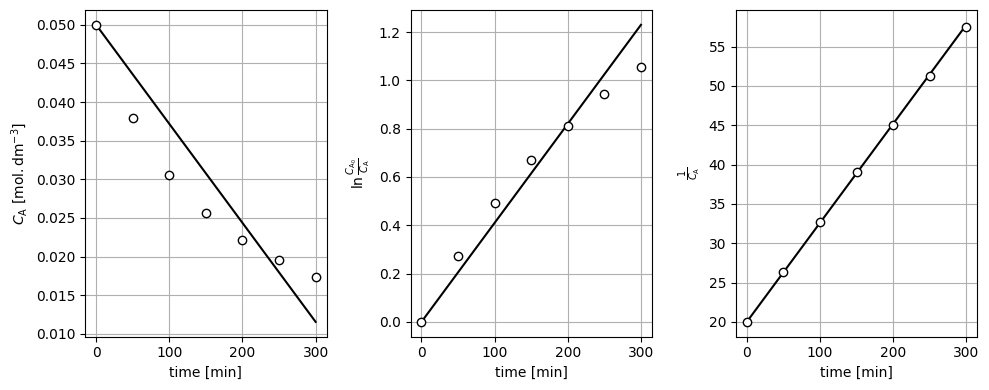

In [5]:
fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(10, 4))
tt = np.linspace(0, 300, 101)

# ajuste de la ley de orden zero (mínimos cuadrados)
ax0.plot(tt, cA0 - k0*tt, color='k')
ax0.plot(t, cA, ls='', marker='o', color='k', markerfacecolor='w')
ax0.set(
    xlabel="time [min]",
    ylabel=r"$C_{\mathrm{A}}$ [$\mathrm{mol.dm^{-3}}$]",
)
ax0.grid()

# ajuste de la ley de orden uno (mínimos cuadrados)
ax1.plot(tt, k1*tt, color='k')
ax1.plot(t, np.log(cA0/cA), ls='', marker='o', color='k', markerfacecolor='w')
ax1.set(
    xlabel="time [min]",
    ylabel=r"$\ln \frac{C_{\mathrm{A_0}}}{C_{\mathrm{A}}}$",
)
ax1.grid()

# ajuste a la ley de orden dos (mínimos cuadrados)
ax2.plot(tt, k2*tt + 1/cA0, color='k')
ax2.plot(t, 1/cA, ls='', marker='o', color='k', markerfacecolor='w')
ax2.set(
    xlabel="time [min]",
    ylabel=r"$\frac{1}{C_{\mathrm{A}}}$",
)
ax2.grid()

fig.tight_layout()
plt.show()

# Fogler, P 7.8

In order to study the photochemical decay of aqueous bromine in bright sunlight, a small quantity of liquid bromine was dissolved in water contained in a glass battery jar and placed in direct sunlight. The following data were obtained at $25$ $\mathrm{^{\circ}C}$:

In [6]:
t = np.array([10, 20, 30, 40, 50, 60]) # t [min]
#t = t-10
cA = np.array([2.45, 1.74, 1.23, 0.8, 0.62, 0.44]) # ppm Br2

**a)** Determine whether the reaction rate is zero, first of second order in bromine, and calculate the reaction-rate constant in units of your choice.

In [7]:
# 0, 1, 2 order kinetics
cA0 = cA[0]
eps = 1e-8

# ajuste de la ley de orden zero (mínimos cuadrados)
params0, cov0 = curve_fit(f=rate_law_0, xdata=t, ydata=cA, bounds=[(eps, eps), (np.inf, np.inf)])
k0 = params0[0]
print(f"Order 0, k = {k0:.2e} [(ppm)/min]")
# ajuste de la ley de orden uno (mínimos cuadrados)
params1, cov1 = curve_fit(f=rate_law_1, xdata=t, ydata=cA, bounds=[(eps, -np.inf), (1, np.inf)])
k1 = params1[0]
print(f"Order 1, k = {k1:.2e} [1/min]")
# ajuste a la ley de orden dos (mínimos cuadrados)
params2, cov2 = curve_fit(f=rate_law_2, xdata=t, ydata=cA, bounds=[(eps, -np.inf), (np.inf, np.inf)])
k2= params2[0]
print(f"Order 2, k = {k2:.2e} [(1/ppm)/min)]")

Order 0, k = 3.95e-02 [(ppm)/min]
Order 1, k = 3.52e-02 [1/min]
Order 2, k = 2.47e-02 [(1/ppm)/min)]


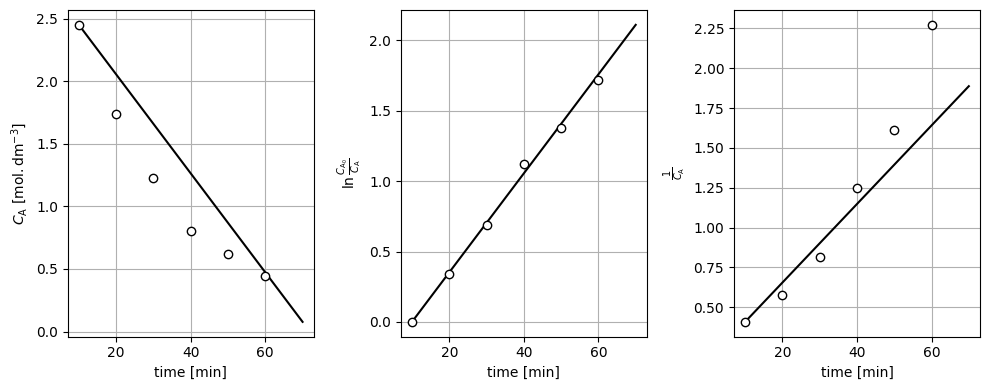

In [8]:
fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(10, 4))
tt = np.linspace(0, 60, 101)

# ajuste de la ley de orden zero (mínimos cuadrados)
ax0.plot(tt+10, cA0 - k0*tt, color='k')
ax0.plot(t, cA, ls='', marker='o', color='k', markerfacecolor='w')
ax0.set(
    xlabel="time [min]",
    ylabel=r"$C_{\mathrm{A}}$ [$\mathrm{mol.dm^{-3}}$]",
)
ax0.grid()

# ajuste de la ley de orden uno (mínimos cuadrados)
ax1.plot(tt+10, k1*tt, color='k')
ax1.plot(t, np.log(cA0/cA), ls='', marker='o', color='k', markerfacecolor='w')
ax1.set(
    xlabel="time [min]",
    ylabel=r"$\ln \frac{C_{\mathrm{A_0}}}{C_{\mathrm{A}}}$",
)
ax1.grid()

# ajuste a la ley de orden dos (mínimos cuadrados)
ax2.plot(tt+10, k2*tt + 1/cA0, color='k')
ax2.plot(t, 1/cA, ls='', marker='o', color='k', markerfacecolor='w')
ax2.set(
    xlabel="time [min]",
    ylabel=r"$\frac{1}{C_{\mathrm{A}}}$",
)
ax2.grid()

fig.tight_layout()
plt.show()

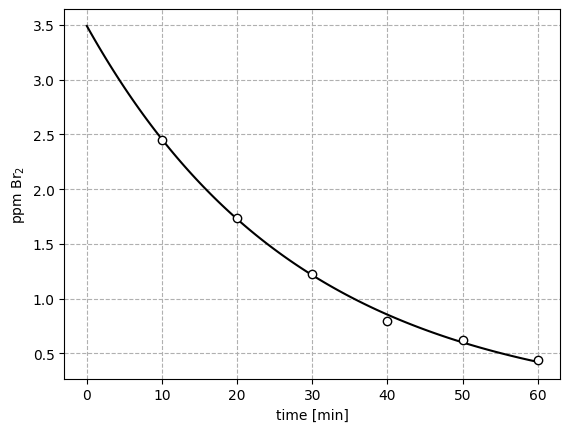

In [9]:
fig, ax = plt.subplots()

tt = np.linspace(0, 60, 121)
ax.plot(tt, rate_law_1(tt, *params1), c='k')
ax.plot(t, cA, ls='', marker='o', color='k', markerfacecolor='w')
ax.set(
    xlabel="time [min]",
    ylabel=r"ppm $\mathrm{Br_2}$"
)
ax.grid(ls='--')
plt.show()

**b)** Assuming identical exposure conditions, calculate the required hourly rate of injection of bromine (in pounds per hour) into a sunlit body of water, $25 000$ gal in volume, in order to maintain a sterilizing level of bromine of $1.0$ ppm.

Initial Br2 level: 8.75 ppm
Critical Br2 level after 60 min: 1.06 ppm


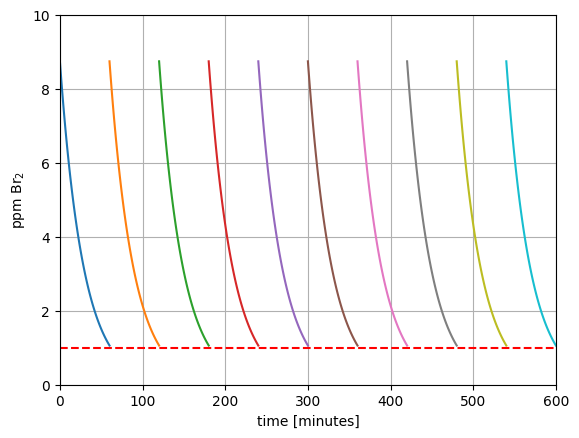

In [10]:
fig, ax = plt.subplots()
C0 = 8.75
ncycles = 10
tCycle = 60
tt = np.linspace(0, tCycle, 121)
cBr2 = rate_law_1(tt, k1, C0)

print(f"Initial Br2 level: {C0:.2f} ppm")
print(f"Critical Br2 level after {tCycle} min: {cBr2[-1]:.2f} ppm")

for cc in range(ncycles):
    ax.plot(tCycle*cc+tt, cBr2)
ax.axhline(1, ls='--', color='r')

ax.set(
    xlabel='time [minutes]',
    ylabel=r'ppm $\mathrm{Br_2}$',
    xlim=(0, tt[-1]*ncycles),
    ylim=(0, 10)
)
ax.grid()

In [11]:
Vwater = 25000 # gallons
Vwater = Vwater * 3.78541 # gallons to liters

mWater = Vwater * 1e-3 # liters to ton

mBr2 = C0 * mWater # g/ton * ton --> g
mBr2 = mBr2 * 2.2e-3 # g --> lb
print(f"Dossage: {mBr2:.2f} lbs of bromine every {tCycle:.2f} minutes")


Dossage: 1.82 lbs of bromine every 60.00 minutes


# Levenspiel, p 3.20

M. Hellin and J. C. Jngers, Bull. soc. chim. France, **386** (1957), present the data in the Table below on the reaction of sulfuric acid with diethylsulfate in aqueous solution at $22.9$ $\mathrm{^{\circ}C}$.

$$\mathrm{H_2SO_4 + (C_2H_5)_2SO_4 \rightarrow 2C_2H_5SO_4H}$$

Initial concentrations of $\mathrm{H_2SO_4}$ and $\mathrm{(C_2H_5)_2SO_4}$ are each $5.5$ $\mathrm{mol.l^{-1}}$. Find a rate equation for this reaction.

**Solución:**

Reescribiendo la ecuación:

$$\mathrm{A + B \rightarrow 2C}$$

tasas de reacción relativas:

$$\frac{r_{\mathrm{A}}}{-1} = \frac{r_{\mathrm{b}}}{-1} = \frac{r_{\mathrm{C}}}{2}$$

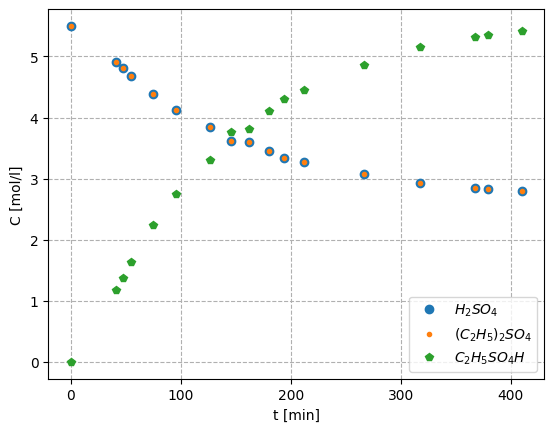

In [12]:
t = np.array([0, 41, 48, 55, 75, 96, 127, 146, 162, 180, 194, 212, 267, 318, 368, 379, 410]) # t [min]
cC = np.array([0, 1.18, 1.38, 1.63, 2.24, 2.75, 3.31, 3.76, 3.81, 4.11, 4.31, 4.45, 4.86, 5.15, 5.32, 5.35, 5.42]) # C2H5SO4H, [mol/l]

# concentraciones de reactivos (tasas de reacción relativas)
cA0, cB0 = 5.5, 5.5
cA = cA0 - (1/2) * cC
cB = cB0 - (1/2) * cC

# gráfico
fig, ax = plt.subplots()
ax.plot(t, cA, marker='o', ls='', label=r"$H_2SO_4$")
ax.plot(t, cB, marker='.', ls='',  label=r"$(C_2H_5)_2SO_4$")
ax.plot(t, cC, marker='p', ls='',  label=r"$C_2H_5SO_4H$")
ax.set(xlabel="t [min]", ylabel="C [mol/l]")
ax.grid(ls='--')
ax.legend()
plt.show()

In [13]:
# 0, 1, 2 order kinetics
cA0 = cA[0]
eps = 1e-8

# ajuste de la ley de orden zero (mínimos cuadrados)
params0, cov0 = curve_fit(f=rate_law_0, xdata=t, ydata=cA, bounds=[(eps, (cA0-eps)), (np.inf, (cA0+eps))])
k0 = params0[0]
print(f"Order 0, k = {k0:.2e} [(mol/dm3)/min]")
# ajuste de la ley de orden uno (mínimos cuadrados)
params1, cov1 = curve_fit(f=rate_law_1, xdata=t, ydata=cA, bounds=[(eps, (cA0-eps)), (1e-2, (cA0+eps))])
k1 = params1[0]
print(f"Order 1, k = {k1:.2e} [1/min]")
# ajuste a la ley de orden dos (mínimos cuadrados)
params2, cov2 = curve_fit(f=rate_law_2, xdata=t, ydata=cA, bounds=[(eps, (cA0-eps)), (np.inf, (cA0+eps))])
k2= params2[0]
print(f"Order 2, k = {k2:.2e} [(dm3/mol)/min)]")
# ajuste a la ley de orden tres (mínimos cuadrados)
params3, cov3 = curve_fit(f=rate_law_3, xdata=t, ydata=cA, bounds=[(eps, (cA0-eps)), (np.inf, (cA0+eps))])
k3= params3[0]
print(f"Order 3, k = {k3:.2e} [(dm3/mol)^2/min)]")

Order 0, k = 8.47e-03 [(mol/dm3)/min]
Order 1, k = 2.19e-03 [1/min]
Order 2, k = 5.44e-04 [(dm3/mol)/min)]
Order 3, k = 1.32e-04 [(dm3/mol)^2/min)]


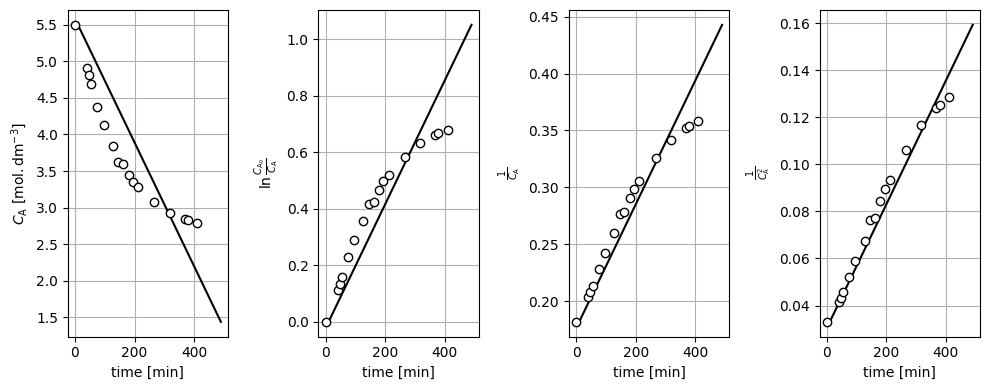

In [ ]:
fig, (ax0, ax1, ax2, ax3) = plt.subplots(ncols=4, figsize=(10, 4))
tt = np.linspace(0, 480, 101)

# ajuste de la ley de orden zero (mínimos cuadrados)
ax0.plot(tt, cA0 - k0*tt, color='k')
ax0.plot(t, cA, ls='', marker='o', color='k', markerfacecolor='w')
ax0.set(
    xlabel="time [min]",
    ylabel=r"$C_{\mathrm{A}}$ [$\mathrm{mol.dm^{-3}}$]",
)
ax0.grid()

# ajuste de la ley de orden uno (mínimos cuadrados)
ax1.plot(tt, k1*tt, color='k')
ax1.plot(t, np.log(cA0/cA), ls='', marker='o', color='k', markerfacecolor='w')
ax1.set(
    xlabel="time [min]",
    ylabel=r"$\ln \frac{C_{\mathrm{A_0}}}{C_{\mathrm{A}}}$",
)
ax1.grid()

# ajuste a la ley de orden dos (mínimos cuadrados)
ax2.plot(tt, k2*tt + 1/cA0, color='k')
ax2.plot(t, 1/cA, ls='', marker='o', color='k', markerfacecolor='w')
ax2.set(
    xlabel="time [min]",
    ylabel=r"$\frac{1}{C_{\mathrm{A}}}$",
)
ax2.grid()

# ajuste a la ley de orden tres (mínimos cuadrados)
ax3.plot(tt, 2*k3*tt + 1/cA0**2, color='k')
ax3.plot(t, 1/cA**2, ls='', marker='o', color='k', markerfacecolor='w')
ax3.set(
    xlabel="time [min]",
    ylabel=r"$\frac{1}{C_{\mathrm{A}}^2}$",
)
ax3.grid()

fig.tight_layout()
plt.show()

Order: 3.04
k = 1.24e-04 [##/min]


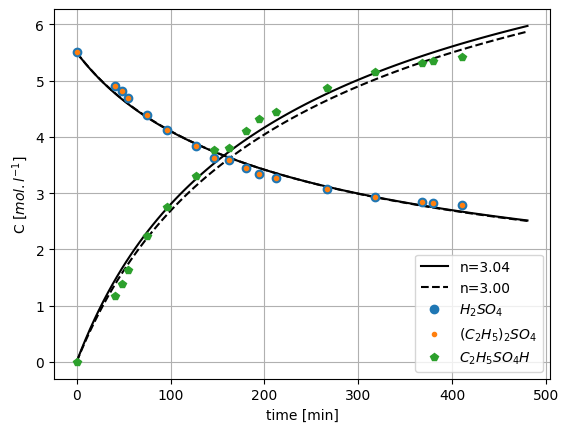

In [15]:
# nth order kinetics
cA0 = cA[0]
eps = 1e-8
# ajuste de la ley de orden uno (mínimos cuadrados)
params, cov = curve_fit(
    f=rate_law_n, 
    xdata=t, 
    ydata=cA, 
    bounds=[(eps, (cA0-eps), 0), (1e-2, (cA0+eps), 5)]
)
kn = params[0]
print(f"Order: {params[2]:.2f}")
print(f"k = {kn:.2e} [##/min]")
nint = np.round(params[2],0)

fig, ax = plt.subplots()
# models
tt = np.linspace(0, 480, 101)
ax.plot(tt, rate_law_n(tt, *params), color='k', label=f"n={params[2]:.2f}")
ax.plot(tt, rate_law_n(tt, k3, cA0, nint), c='k', ls='--', label=f"n={nint:.2f}")
ax.plot(tt, 2*(cA0-rate_law_n(tt, *params)), color='k')
ax.plot(tt, 2*(cA0-rate_law_n(tt, kn, cA0, nint)), c='k', ls='--')
# data
ax.plot(t, cA, marker='o', ls='', label=r"$H_2SO_4$")
ax.plot(t, cB, marker='.', ls='',  label=r"$(C_2H_5)_2SO_4$")
ax.plot(t, cC, marker='p', ls='',  label=r"$C_2H_5SO_4H$")
ax.set(
    xlabel="time [min]",
    ylabel=r"C $[mol.l^{-1}]$",
)
ax.legend()
ax.grid()
plt.show()

# Referencias

- ***[Fogler, 2016]***: Fogler, H. S. (2016) Elements of Chemical Reaction Engineering (5th ed.). Prentice Education Inc.

- ***[Levenspiel, 1998]***: Levenspiel, O. (1998) Chemical Reaction Engineering (3rd ed.). John Wiley & Sons Inc. URL: https://www.wiley.com/en-no/Chemical+Reaction+Engineering%2C+3rd+Edition-p-9780471254249